## MobileNetv2 Training 

In [7]:
import os
import time
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
from pathlib import Path
import copy

# CONFIGURACIÓN GENERAL
data_dir = Path(r"C:\Users\alexa\Desktop\yolov4\Imagenes")
batch_size = 64
num_epochs = 30
learning_rate = 0.001
num_classes = 38
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TRANSFORMACIONES
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply([
            transforms.ColorJitter(0.3, 0.3, 0.3),
            transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
            transforms.GaussianBlur(kernel_size=3)
        ], p=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

# DATASETS Y DATALOADERS
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'valid']
}
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True, num_workers=2)
    for x in ['train', 'valid']
}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid']}
class_names = image_datasets['train'].classes

# MODELO
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, num_classes)
)
model = model.to(device)

# CRITERIO Y OPTIMIZADOR
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.3)

# ENTRENAMIENTO
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

for epoch in range(num_epochs):
    print(f"\n🔁 Época {epoch + 1}/{num_epochs}")
    print("-" * 30)

    for phase in ['train', 'valid']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(dataloaders[phase], desc=f"🔄 {phase}"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

        # Actualiza el scheduler solo con validación
        if phase == 'valid':
            scheduler.step(epoch_loss)

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

# GUARDAR MODELO
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), "mobilenetv2_finetuned_optimized.pth")
print(f"\n✅ Entrenamiento finalizado. Mejor acc validación: {best_acc:.4f}")



🔁 Época 1/30
------------------------------


🔄 train: 100%|████████████████████████████████████████████████████████████████████| 2197/2197 [03:50<00:00,  9.52it/s]


Train Loss: 1.1752 Acc: 0.8564


🔄 valid: 100%|██████████████████████████████████████████████████████████████████████| 550/550 [00:32<00:00, 16.93it/s]


Valid Loss: 0.8263 Acc: 0.9737

🔁 Época 2/30
------------------------------


...

Valid Loss: 0.6794 Acc: 0.9985

🔁 Época 30/30
------------------------------


🔄 train: 100%|████████████████████████████████████████████████████████████████████| 2197/2197 [03:51<00:00,  9.48it/s]


Train Loss: 0.7236 Acc: 0.9868


🔄 valid: 100%|██████████████████████████████████████████████████████████████████████| 550/550 [00:32<00:00, 17.01it/s]

Valid Loss: 0.6789 Acc: 0.9982

✅ Entrenamiento finalizado. Mejor acc validación: 0.9985


## Testing con dataset de internet

Predicciones guardadas en 'predictions_with_truth.csv'

Accuracy global: 0.5200

Classification Report:
                                          precision    recall  f1-score   support

                         Apple_Black_rot       1.00      0.50      0.67         2
                  Apple_Cedar_apple_rust       0.00      0.00      0.00         3
                           Apple_healthy       1.00      0.25      0.40         4
                              Apple_scab       0.00      0.00      0.00         0
                       Blueberry_healthy       1.00      1.00      1.00         3
                   Cherry_Powdery_mildew       0.00      0.00      0.00         0
                          Cherry_healthy       0.00      0.00      0.00         0
Corn_Cercospora_leaf_spot_Gray_leaf_spot       0.00      0.00      0.00         0
                        Corn_Common_rust       0.00      0.00      0.00         2
               Corn_Northern_Leaf_Blight       0.00      0.00      0.00    

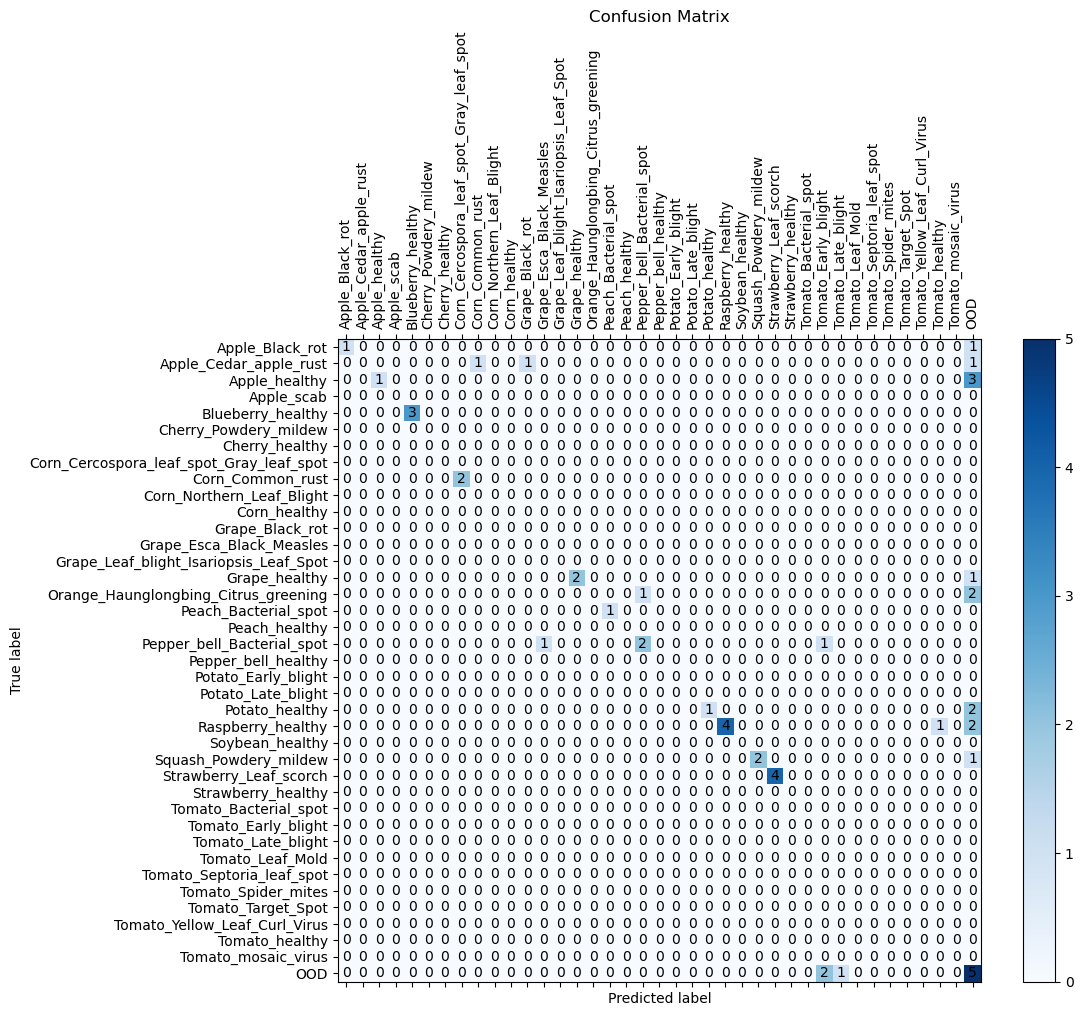


Resumen de predicciones:
                                   label  count  percentage
                                     OOD     18        36.0
                         Apple_Black_rot      1         2.0
                         Grape_Black_rot      1         2.0
                        Corn_Common_rust      1         2.0
                           Apple_healthy      1         2.0
                       Blueberry_healthy      3         6.0
Corn_Cercospora_leaf_spot_Gray_leaf_spot      2         4.0
                           Grape_healthy      2         4.0
              Pepper_bell_Bacterial_spot      3         6.0
                    Peach_Bacterial_spot      1         2.0
                Grape_Esca_Black_Measles      1         2.0
                     Tomato_Early_blight      3         6.0
                          Potato_healthy      1         2.0
                       Raspberry_healthy      4         8.0
                          Tomato_healthy      1         2.0
              

In [3]:
import os
import torch
from torchvision import models, transforms
from PIL import Image
from collections import OrderedDict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 1. Configuración de rutas y dispositivo
model_path = r"C:\Users\alexa\Desktop\yolov4\models\mobilenetv2_finetuned_optimized.pth"
#model_path ="mobilenetv2_best.pth"
test_dir   = r"C:\Users\alexa\Desktop\yolov4\testing"
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Definir lista de clases planta
classes = [
    'Apple_Black_rot','Apple_Cedar_apple_rust','Apple_healthy','Apple_scab',
    'Blueberry_healthy','Cherry_Powdery_mildew','Cherry_healthy',
    'Corn_Cercospora_leaf_spot_Gray_leaf_spot','Corn_Common_rust',
    'Corn_Northern_Leaf_Blight','Corn_healthy','Grape_Black_rot',
    'Grape_Esca_Black_Measles','Grape_Leaf_blight_Isariopsis_Leaf_Spot',
    'Grape_healthy','Orange_Haunglongbing_Citrus_greening',
    'Peach_Bacterial_spot','Peach_healthy','Pepper_bell_Bacterial_spot',
    'Pepper_bell_healthy','Potato_Early_blight','Potato_Late_blight',
    'Potato_healthy','Raspberry_healthy','Soybean_healthy',
    'Squash_Powdery_mildew','Strawberry_Leaf_scorch','Strawberry_healthy',
    'Tomato_Bacterial_spot','Tomato_Early_blight','Tomato_Late_blight',
    'Tomato_Leaf_Mold','Tomato_Septoria_leaf_spot','Tomato_Spider_mites',
    'Tomato_Target_Spot','Tomato_Yellow_Leaf_Curl_Virus','Tomato_healthy',
    'Tomato_mosaic_virus'
]
all_classes = classes + ["OOD"]

# 3. Transform para inferencia
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# 4. Cargar y montar el modelo
model = models.mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(model.last_channel, len(classes))

checkpoint = torch.load(model_path, map_location=device)
new_state  = OrderedDict()
for k,v in checkpoint.items():
    nk = k.replace("classifier.1.1","classifier.1") if k.startswith("classifier.1.1") else k
    new_state[nk] = v
model.load_state_dict(new_state)
model.to(device).eval()

# 5. Umbral OOD
ood_threshold = 0.5

# 6. Inferencia y recolección de resultados
results = []
for fname in sorted(os.listdir(test_dir)):
    if not fname.lower().endswith((".jpg",".jpeg",".png")):
        continue

    # extraer etiqueta real antes del último "_"
    base = os.path.splitext(fname)[0]
    raw = base.rsplit('_', 1)[0]
    true_label = raw if raw in classes else "OOD"

    img = Image.open(os.path.join(test_dir, fname)).convert("RGB")
    x   = test_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)[0].cpu()
    max_prob, idx = probs.max(0)
    pred_label = "OOD" if max_prob < ood_threshold else classes[idx]

    results.append({
        "filename":   fname,
        "true":       true_label,
        "predicted":  pred_label,
        "confidence": float(max_prob)
    })

# 7. Guardar todas las predicciones
df = pd.DataFrame(results)
df.to_csv("predictions_with_truth.csv", index=False)
print("Predicciones guardadas en 'predictions_with_truth.csv'")

# 8. Cálculo de métricas
y_true = df["true"]
y_pred = df["predicted"]

acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy global: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(
    y_true, y_pred,
    labels=all_classes,
    zero_division=0
))

# 9. Matriz de confusión numérica
cm = confusion_matrix(y_true, y_pred, labels=all_classes)

# 10. Dibujo de la matriz de confusión
fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.matshow(cm, cmap=plt.cm.Blues)
fig.colorbar(cax, ax=ax)
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, val, ha='center', va='center')
ax.set_xticks(range(len(all_classes)))
ax.set_yticks(range(len(all_classes)))
ax.set_xticklabels(all_classes, rotation=90)
ax.set_yticklabels(all_classes)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

# 11. Resumen de predicciones
counter = Counter(df["predicted"])
summary_df = pd.DataFrame.from_dict(counter, orient='index', columns=['count'])
summary_df['percentage'] = (summary_df['count'] / len(df) * 100).round(2)
summary_df = summary_df.reset_index().rename(columns={'index':'label'})
print("\nResumen de predicciones:")
print(summary_df.to_string(index=False))


## Cuantización dinámica + TorchScript (Optimización para raspberry pi 5)

In [3]:
import torch
from torchvision import models
from collections import OrderedDict
from torch.quantization import quantize_dynamic

# 1. Define número de clases
num_classes = 38

# 2. Carga arquitectura
model = models.mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(model.last_channel, num_classes)

# 3. Carga checkpoint y renombra keys
ckpt = torch.load("mobilenetv2_finetuned_optimized.pth", map_location="cpu")
new_state = OrderedDict()
for k, v in ckpt.items():
    if k.startswith("classifier.1.1."):
        # pasa classifier.1.1.weight → classifier.1.weight, etc.
        nk = k.replace("classifier.1.1.", "classifier.1.")
    else:
        nk = k
    new_state[nk] = v
model.load_state_dict(new_state)
model.eval()

# 4. Cuantiza dinámicamente las capas Linear
quantized_model = quantize_dynamic(
    model,
    {torch.nn.Linear},
    dtype=torch.qint8
)

# 5. Traza con un dummy input
dummy = torch.randn(1, 3, 224, 224)
traced = torch.jit.trace(quantized_model, dummy)
traced = torch.jit.optimize_for_inference(traced)

# 6. Guarda el modelo trazado
traced.save("mobilenetv2_pi_traced.pt")
print("¡Modelo trazado y guardado como mobilenetv2_pi_traced.pt!")


¡Modelo trazado y guardado como mobilenetv2_pi_traced.pt!


In [15]:
import torch
from torchvision import models
from collections import OrderedDict

# 1. Monta el modelo e importa pesos
model = models.mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(model.last_channel, 38)

ckpt = torch.load("mobilenetv2_finetuned_optimized.pth", map_location="cpu")
new_sd = OrderedDict()
for k,v in ckpt.items():
    nk = k.replace("classifier.1.1", "classifier.1") if k.startswith("classifier.1.1") else k
    new_sd[nk] = v
model.load_state_dict(new_sd)
model.eval()

# 2. Export a ONNX (float32)
dummy = torch.randn(1, 3, 224, 224)
torch.onnx.export(
    model,
    dummy,
    "mobilenetv2_fp32.onnx",
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={"input":{0:"batch"}, "logits":{0:"batch"}},
    opset_version=13
)
print("✅ Exportado float32 ONNX → mobilenetv2_fp32.onnx")


✅ Exportado float32 ONNX → mobilenetv2_fp32.onnx


In [9]:
from onnxruntime.quantization import quantize_dynamic, QuantType

# Quantize solo las Gemm (usadas por Linear)
quantize_dynamic(
    "mobilenetv2_fp32.onnx",    # tu ONNX original en float32
    "mobilenetv2_q8.onnx",      # salida quantizada
    weight_type=QuantType.QInt8,
    op_types_to_quantize=["Gemm"]
)

print("✅ ONNX quantizado correctamente (solo Gemm).")


✅ ONNX quantizado correctamente (solo Gemm).


## Curvas de rendimiento

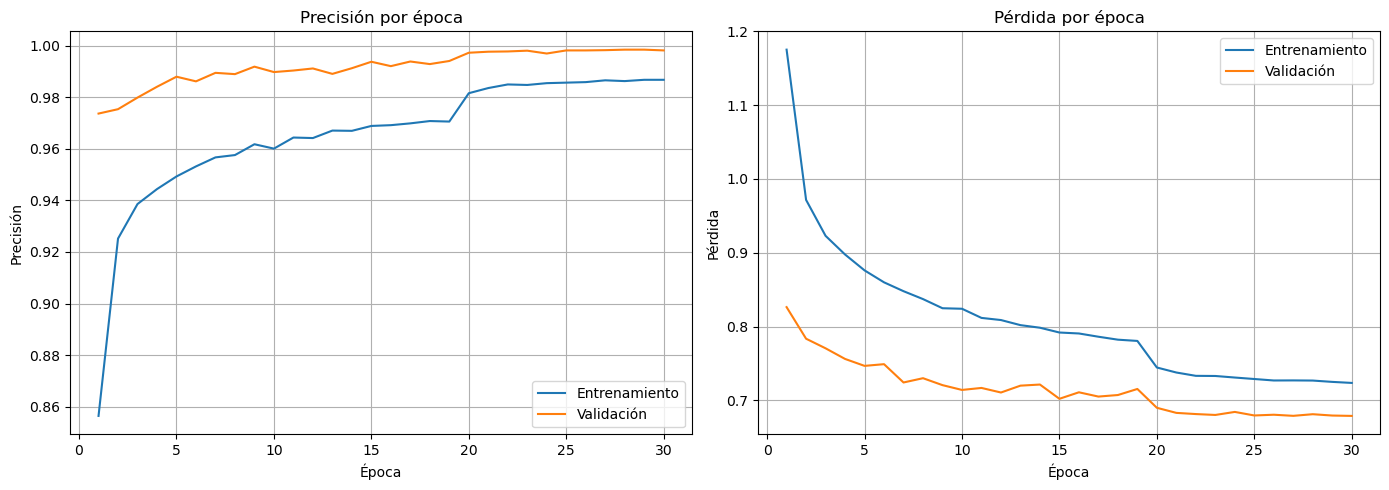

In [18]:
import matplotlib.pyplot as plt

epochs = list(range(1, 31))
train_acc = [0.8564, 0.9252, 0.9386, 0.9444, 0.9493, 0.9532, 0.9567, 0.9576, 0.9618, 0.9601,
             0.9644, 0.9642, 0.9671, 0.9670, 0.9689, 0.9692, 0.9699, 0.9708, 0.9706, 0.9816,
             0.9836, 0.9850, 0.9848, 0.9855, 0.9857, 0.9859, 0.9866, 0.9863, 0.9868, 0.9868]
val_acc = [0.9737, 0.9754, 0.9799, 0.9841, 0.9880, 0.9862, 0.9895, 0.9890, 0.9919, 0.9898,
           0.9904, 0.9912, 0.9891, 0.9913, 0.9938, 0.9921, 0.9939, 0.9929, 0.9941, 0.9973,
           0.9977, 0.9978, 0.9981, 0.9970, 0.9982, 0.9982, 0.9983, 0.9985, 0.9985, 0.9982]
train_loss = [1.1752, 0.9716, 0.9229, 0.8976, 0.8761, 0.8599, 0.8479, 0.8372, 0.8248, 0.8241,
              0.8117, 0.8088, 0.8019, 0.7984, 0.7919, 0.7906, 0.7862, 0.7822, 0.7805, 0.7445,
              0.7377, 0.7332, 0.7330, 0.7309, 0.7289, 0.7269, 0.7270, 0.7268, 0.7250, 0.7236]
val_loss = [0.8263, 0.7835, 0.7705, 0.7561, 0.7467, 0.7490, 0.7242, 0.7300, 0.7206, 0.7141,
            0.7168, 0.7106, 0.7199, 0.7214, 0.7021, 0.7109, 0.7051, 0.7072, 0.7154, 0.6899,
            0.6830, 0.6814, 0.6802, 0.6843, 0.6795, 0.6805, 0.6790, 0.6812, 0.6794, 0.6789]

plt.figure(figsize=(14, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Entrenamiento')
plt.plot(epochs, val_acc, label='Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Precisión por época')
plt.legend()
plt.grid(True)

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Entrenamiento')
plt.plot(epochs, val_loss, label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Pérdida por época')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Analisis de imagenes de Internet

In [16]:
import os
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import pandas as pd
from pathlib import Path

# CONFIGURACIÓN
image_dir = Path(r"C:\Users\alexa\Desktop\yolov4\testing")
model_path = Path(r"C:\Users\alexa\mobilenetv2_finetuned_optimized.pth")
num_classes = 38
threshold_ood = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TRANSFORMACIONES
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# CARGAR MODELO
model = models.mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(model.last_channel, num_classes)
)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# PROCESAR IMÁGENES
results = []
for fname in os.listdir(image_dir):
    if fname.lower().endswith((".jpg", ".png", ".jpeg")):
        try:
            image_path = image_dir / fname
            image = Image.open(image_path).convert("RGB")
            input_tensor = transform(image).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(input_tensor)
                prob = F.softmax(output, dim=1)
                conf, pred = torch.max(prob, 1)
                conf = conf.item()
                pred_label = pred.item()
                ood = conf < threshold_ood
                true_label = fname.rsplit("_", 1)[0]

                results.append({
                    "image": fname,
                    "true_label": true_label,
                    "predicted_class": pred_label,
                    "confidence": conf,
                    "is_OOD": ood
                })
        except Exception as e:
            results.append({
                "image": fname,
                "true_label": "ERROR",
                "predicted_class": "ERROR",
                "confidence": "ERROR",
                "is_OOD": True
            })

# GUARDAR RESULTADOS
df = pd.DataFrame(results)
df.to_csv("inferencia_OOD_results.csv", index=False)
print("✅ Resultados guardados en 'inferencia_OOD_results.csv'")


✅ Resultados guardados en 'inferencia_OOD_results.csv'


In [11]:
import os
import torch
import pandas as pd
from torchvision import models, transforms
from PIL import Image
import torch.nn as nn

# === CONFIGURACIÓN ===
model_path = r"C:\Users\alexa\Desktop\yolov4\models\mobilenetv2_finetuned_optimized.pth"
image_dir = r"C:\Users\alexa\Desktop\yolov4\testing"
umbral_confianza = 0.4
num_classes = 38

# === TRANSFORMACIONES ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# === MODELO ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.mobilenet_v2(weights=None)
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, num_classes)
)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# === INFERENCIA ===
results = []
for image_file in os.listdir(image_dir):
    if not image_file.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    image_path = os.path.join(image_dir, image_file)
    try:
        image = Image.open(image_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            prob = torch.nn.functional.softmax(output, dim=1)
            conf, pred_class = torch.max(prob, 1)

        predicted_class = pred_class.item()
        confidence = conf.item()

        true_class = image_file.split(".jpg")[0]
        if "_" in true_class:
            parts = true_class.split("_")
            if parts[-1].isdigit():
                true_class = "_".join(parts[:-1])

        is_ood = confidence < umbral_confianza

        results.append({
            "image": image_file,
            "true_label": true_class,
            "predicted_class": predicted_class,
            "confidence": confidence,
            "is_OOD": is_ood
        })

    except Exception as e:
        print(f"Error con {image_file}: {e}")
        continue

# === GUARDAR RESULTADOS ===
df = pd.DataFrame(results)
df.to_csv("inferencia_mobilenetv2_results.csv", index=False)
print("✅ Resultados guardados en 'inferencia_mobilenetv2_results.csv'")


✅ Resultados guardados en 'inferencia_mobilenetv2_results.csv'
